# Autocorrelation Analysis of NumPy's Default RNG

This notebook analyses the **autocorrelation properties** of NumPy's default
pseudo-random number generator (PCG64) and demonstrates three ways to estimate
the standard deviation of the mean when samples may be correlated.

### Contents
1. [Background & Notation](#1-background)
2. [Imports & Setup](#2-imports)
3. [Generating RNG Samples](#3-samples)
4. [Autocorrelation Function](#4-acf)
5. [Integrated Autocorrelation Time τ_int](#5-tauint)
6. [Standard Deviation — Naive Method](#6-naive)
7. [Standard Deviation — Covariance Method](#7-covariance)
8. [Standard Deviation — Bootstrap Method](#8-bootstrap)
9. [Comparison Across Sample Sizes](#9-comparison)
10. [Summary](#10-summary)


---
## 1. Background & Notation <a id='1-background'></a>

### 1.1 The PCG64 Generator

NumPy's `default_rng()` uses the **PCG64** (Permuted Congruential Generator,
64-bit) algorithm, which passes all standard statistical tests and has an
astronomically long period of $2^{128}$.

### 1.2 Normalised Autocorrelation Function

Given a time series $\{x_i\}_{i=1}^{N}$ with mean $\bar{x}$ and variance
$\sigma^2 = \langle (x_i - \bar{x})^2 \rangle$, the **normalised
autocorrelation function** at lag $t$ is:

$$\boxed{C(t) = \frac{\langle (x_i - \bar{x})(x_{i+t} - \bar{x}) \rangle}{\sigma^2}}$$

By construction $C(0) = 1$, and for uncorrelated data $C(t) = 0$ for all
$t \geq 1$.

**FFT-based computation** reduces the cost from $O(N^2)$ to $O(N \log N)$:

$$C(t) = \frac{1}{(N-t)\,\sigma^2}\,\text{IFFT}\!\left[|\text{FFT}[x_c]|^2\right](t)$$

where $x_c = x - \bar{x}$.

### 1.3 Variance of the Sample Mean

For a **correlated** time series the true variance of the sample mean is:

$$\text{Var}(\bar{x}) = \frac{1}{N^2} \sum_{i,j=1}^{N} \text{Cov}(x_i, x_j)
= \frac{\sigma^2}{N} \sum_{t=-(N-1)}^{N-1} \left(1 - \frac{|t|}{N}\right) C(t)
\approx \frac{2\,\tau_{\rm int}\,\sigma^2}{N}$$

Hence the **corrected standard deviation of the mean** is:

$$\boxed{\sigma_{\bar{x}}^{\rm corr} = \sigma \sqrt{\frac{2\,\tau_{\rm int}}{N}}}$$

The naive estimate assumes $\tau_{\rm int} = 1/2$ (no correlations):

$$\sigma_{\bar{x}}^{\rm naive} = \frac{\sigma}{\sqrt{N}}$$

### 1.4 Integrated Autocorrelation Time

$$\boxed{\tau_{\rm int} = \frac{1}{2} + \sum_{t=1}^{W} C(t)}$$

The sum is truncated at window $W$ chosen by the **Madras–Sokal
automatic-windowing** criterion: stop at the first $W$ with
$W < c \cdot \tau_{\rm int}$ (typically $c = 6$).

### 1.5 Bootstrap Estimator

For correlated data, use **circular block bootstrapping**: resample blocks
of consecutive observations of length $b \sim \tau_{\rm int}$ with
replacement, then compute the standard deviation of the bootstrap
distribution of the mean:

$$\hat{\sigma}_{\bar{x}}^{\rm boot} = \text{std}\!\left[\{\bar{x}^{(k)}\}_{k=1}^{B}\right]$$

For i.i.d. uniform $[0,1)$ data the exact value is
$\sigma_{\bar{x}} = 1 / \sqrt{12 N}$.


---
## 2. Imports & Setup <a id='2-imports'></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Plot styling ──────────────────────────────────────────────────────
BG     = "#0d0f1a"
PANEL  = "#131629"
ACCENT = "#4fc3f7"
WARM   = "#ff7043"
GREEN  = "#69f0ae"
PURPLE = "#ce93d8"
GRID   = "#1e2340"
TEXT   = "#e8eaf6"

def apply_dark_style():
    plt.rcParams.update({
        'figure.facecolor':  BG,   'axes.facecolor':  PANEL,
        'axes.edgecolor':    GRID, 'axes.labelcolor': TEXT,
        'xtick.color':       TEXT, 'ytick.color':     TEXT,
        'text.color':        TEXT, 'grid.color':      GRID,
        'grid.linewidth':    0.6,  'legend.facecolor':PANEL,
        'legend.edgecolor':  GRID,
    })

apply_dark_style()
print("Imports OK — NumPy", np.__version__)


Imports OK — NumPy 1.22.3


---
## 3. Generating RNG Samples <a id='3-samples'></a>

In [2]:
def generate_sample(N: int, seed: int = 42) -> np.ndarray:
    """Draw N uniform [0,1) samples from NumPy's default PCG64 RNG."""
    rng = np.random.default_rng(seed)
    return rng.random(N)

N    = 50_000
SEED = 42
x    = generate_sample(N, seed=SEED)

print(f"N          = {N}")
print(f"Min        = {x.min():.6f}  (expect ~0)")
print(f"Max        = {x.max():.6f}  (expect ~1)")
print(f"Mean       = {x.mean():.6f}  (expect 0.5)")
print(f"Std        = {x.std():.6f}  (expect {1/np.sqrt(12):.6f}  =  1/√12)")


N          = 50000
Min        = 0.000013  (expect ~0)
Max        = 0.999994  (expect ~1)
Mean       = 0.500891  (expect 0.5)
Std        = 0.288617  (expect 0.288675  =  1/√12)


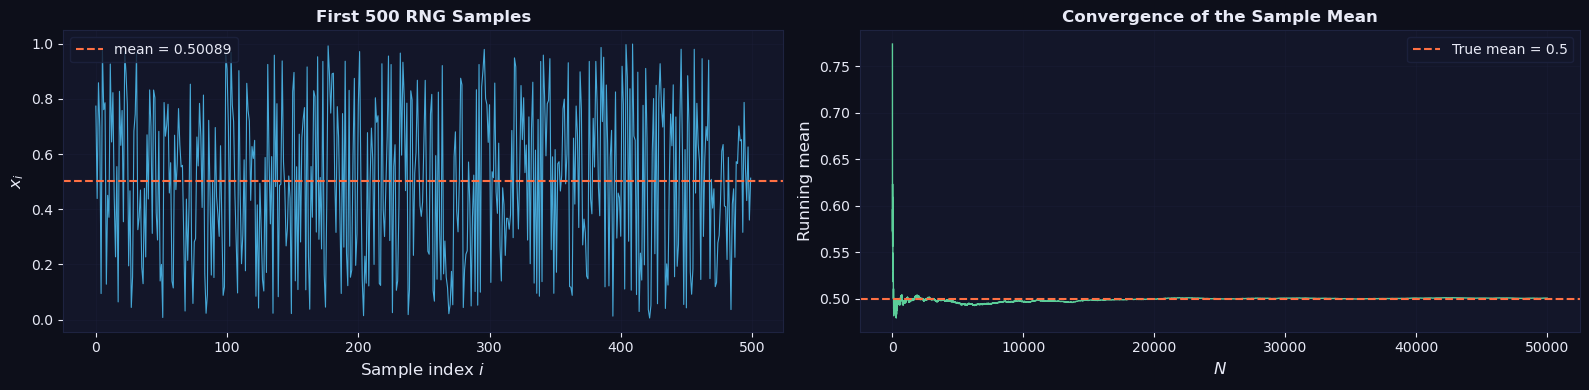

In [3]:
# ── Plot raw samples and running mean ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(x[:500], color=ACCENT, lw=0.8, alpha=0.85)
axes[0].axhline(x.mean(), color=WARM, lw=1.5, ls='--',
                label=f'mean = {x.mean():.5f}')
axes[0].set_xlabel('Sample index $i$', fontsize=12)
axes[0].set_ylabel('$x_i$', fontsize=12)
axes[0].set_title('First 500 RNG Samples', fontweight='bold', color=TEXT)
axes[0].legend(); axes[0].grid(True, alpha=0.35)

running = np.cumsum(x) / np.arange(1, N + 1)
axes[1].plot(running, color=GREEN, lw=1.0, alpha=0.85)
axes[1].axhline(0.5, color=WARM, lw=1.5, ls='--', label='True mean = 0.5')
axes[1].set_xlabel('$N$', fontsize=12)
axes[1].set_ylabel('Running mean', fontsize=12)
axes[1].set_title('Convergence of the Sample Mean', fontweight='bold', color=TEXT)
axes[1].legend(); axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.show()


---
## 4. Autocorrelation Function <a id='4-acf'></a>

We compute the **normalised ACF** using the FFT-based algorithm:

$$C(t) = \frac{\text{IFFT}\!\left[|\text{FFT}[x_c]|^2\right](t)}{(N-t)\,\sigma^2}$$

The 95% **confidence band** under the null hypothesis $C(t)=0$ is
$\pm 1.96 / \sqrt{N}$.


In [4]:
def autocorrelation(x: np.ndarray, max_lag: int = None) -> np.ndarray:
    """
    Normalised autocorrelation C(t) via FFT.  Returns C(0)..C(max_lag).

    C(t) = <(x_i - <x>)(x_{i+t} - <x>)> / Var(x)
    """
    N = len(x)
    if max_lag is None:
        max_lag = N // 2
    max_lag = min(max_lag, N - 1)

    xc  = x - x.mean()
    # Zero-pad to next power of 2 for efficient FFT
    fft_size = 1
    while fft_size < 2 * N:
        fft_size <<= 1

    F   = np.fft.rfft(xc, n=fft_size)
    acf = np.fft.irfft(F * np.conj(F))[:N]
    counts = N - np.arange(N)          # number of pairs at each lag
    acf    = acf / counts          # normalise by number of pairs at each lag
    acf    = acf / acf[0]          # normalise so C(0) = 1  (= variance at lag 0)
    return acf[:max_lag + 1]

MAX_LAG = 200
acf = autocorrelation(x, max_lag=MAX_LAG)
print(f"C(0) = {acf[0]:.6f}  (should be 1.0)")
print(f"C(1) = {acf[1]:.6f}  (expect ~0 for good RNG)")
print(f"C(2) = {acf[2]:.6f}")
print(f"max|C(t)| for t>=1 : {np.max(np.abs(acf[1:])):.6f}")


C(0) = 1.000000  (should be 1.0)
C(1) = -0.003091  (expect ~0 for good RNG)
C(2) = 0.001479
max|C(t)| for t>=1 : 0.015256


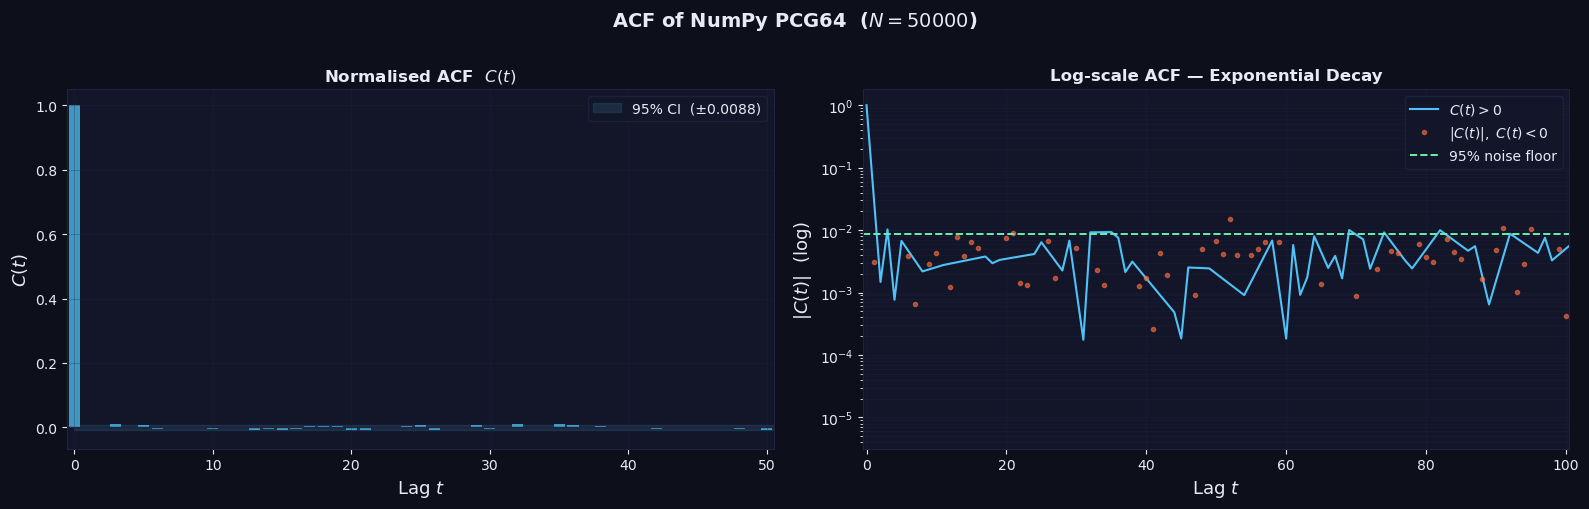

In [5]:
# ── Plot ACF ──────────────────────────────────────────────────────────
lags = np.arange(len(acf))
conf = 1.96 / np.sqrt(N)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: bar plot
ax = axes[0]
ax.axhline(0, color=GRID, lw=1)
ax.fill_between(lags, -conf, conf, color=ACCENT, alpha=0.12,
                label=f'95% CI  (±{conf:.4f})')
ax.bar(lags, acf, color=ACCENT, alpha=0.75, width=0.8)
ax.set_xlabel('Lag $t$', fontsize=13)
ax.set_ylabel('$C(t)$', fontsize=13)
ax.set_title('Normalised ACF  $C(t)$', fontweight='bold', color=TEXT)
ax.set_xlim(-0.5, 50.5)
ax.legend(fontsize=10); ax.grid(True, alpha=0.35)

# Right: log scale
ax2 = axes[1]
pos = acf > 0
ax2.semilogy(lags[pos],  acf[pos],          color=ACCENT, lw=1.5, label='$C(t)>0$')
ax2.semilogy(lags[~pos], np.abs(acf[~pos]), 'o', color=WARM, ms=3, alpha=0.6,
             label='$|C(t)|,\ C(t)<0$')
ax2.axhline(conf, color=GREEN, lw=1.4, ls='--', label='95% noise floor')
ax2.set_xlabel('Lag $t$', fontsize=13)
ax2.set_ylabel('$|C(t)|$  (log)', fontsize=13)
ax2.set_title('Log-scale ACF — Exponential Decay', fontweight='bold', color=TEXT)
ax2.set_xlim(-0.5, 100.5)
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.35, which='both')

plt.suptitle(f'ACF of NumPy PCG64  ($N={N}$)',
             fontsize=14, fontweight='bold', color=TEXT, y=1.01)
plt.tight_layout()
plt.show()


---
## 5. Integrated Autocorrelation Time $\tau_{\rm int}$ <a id='5-tauint'></a>

$$\tau_{\rm int} = \frac{1}{2} + \sum_{t=1}^{W} C(t)$$

The window $W$ is chosen by the **Madras–Sokal criterion**: advance $t$ until
$t \geq c\,\tau_{\rm int}$ (with $c=6$). This prevents the noise in the
tail of $C(t)$ from inflating $\tau_{\rm int}$.

The minimum possible value is $\tau_{\rm int} = 1/2$, corresponding to
perfectly uncorrelated data.


In [6]:
def integrated_autocorrelation_time(acf: np.ndarray,
                                     c_factor: float = 6.0) -> tuple:
    """
    Estimate tau_int = 1/2 + sum_{t=1}^{W} C(t)
    using the Madras-Sokal automatic-windowing rule.
    Returns (tau_int, window W).
    """
    tau = 0.5
    for t in range(1, len(acf)):
        tau += acf[t]
        if t >= c_factor * tau:
            return tau, t
    return tau, len(acf) - 1

tau_int, W = integrated_autocorrelation_time(acf)
print(f"tau_int = {tau_int:.4f}   (1/2 = uncorrelated)")
print(f"Window  W = {W}")
print(f"Effective sample size  N_eff = N / (2*tau_int) = {N / (2*tau_int):.1f}")


tau_int = 0.5094   (1/2 = uncorrelated)
Window  W = 4
Effective sample size  N_eff = N / (2*tau_int) = 49076.8


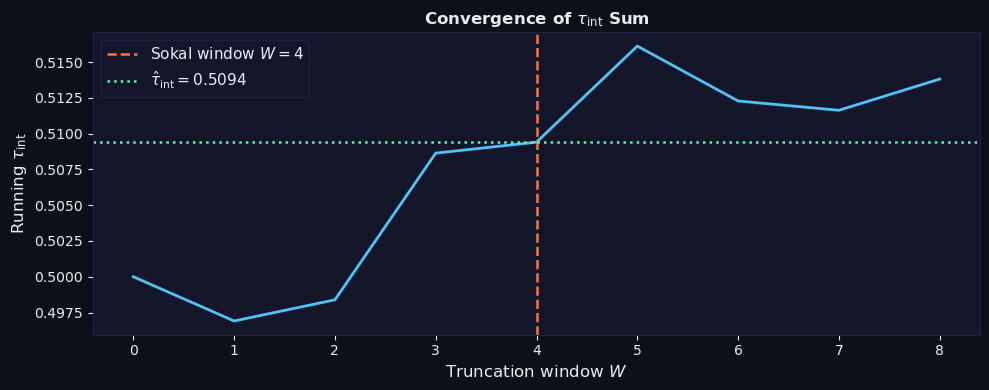

In [7]:
# ── Visualise the running sum converging to tau_int ───────────────────
running_tau = np.cumsum(np.concatenate([[0.5], acf[1:W+5]]))
# fix: running_tau[t] = 0.5 + sum_{s=1}^{t} C(s)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(running_tau)), running_tau, color=ACCENT, lw=2)
ax.axvline(W, color=WARM, lw=1.8, ls='--', label=f'Sokal window $W={W}$')
ax.axhline(tau_int, color=GREEN, lw=1.8, ls=':', label=f'$\\hat{{\\tau}}_{{\\rm int}}={tau_int:.4f}$')
ax.set_xlabel('Truncation window $W$', fontsize=12)
ax.set_ylabel('Running $\\tau_{\\rm int}$', fontsize=12)
ax.set_title('Convergence of $\\tau_{\\rm int}$ Sum', fontweight='bold', color=TEXT)
ax.legend(fontsize=11); ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()


---
## 6. Standard Deviation — Naive Method <a id='6-naive'></a>

The **naive** estimator assumes the $N$ samples are i.i.d.:

$$\sigma_{\bar{x}}^{\rm naive} = \frac{s}{\sqrt{N}}, \qquad
s^2 = \frac{1}{N-1}\sum_{i=1}^{N}(x_i - \bar{x})^2$$

For uncorrelated uniform $[0,1)$ data the exact value is
$\sigma_{\bar{x}} = 1/\sqrt{12N}$.

This estimator is **biased low** whenever $\tau_{\rm int} > 1/2$.


In [8]:
def std_naive(x: np.ndarray) -> float:
    """Naive sigma_mean = std(x) / sqrt(N), assumes i.i.d."""
    return float(np.std(x, ddof=1) / np.sqrt(len(x)))

sigma_naive = std_naive(x)
exact       = 1.0 / (np.sqrt(12) * np.sqrt(N))

print(f"Naive sigma_mean = {sigma_naive:.8f}")
print(f"Exact (i.i.d.)   = {exact:.8f}")
print(f"Ratio            = {sigma_naive / exact:.6f}  (expect 1.0 for good RNG)")


Naive sigma_mean = 0.00129075
Exact (i.i.d.)   = 0.00129099
Ratio            = 0.999809  (expect 1.0 for good RNG)


---
## 7. Standard Deviation — Covariance Method <a id='7-covariance'></a>

The exact variance of the mean for a **stationary** process is:

$$\text{Var}(\bar{x}) = \frac{\sigma^2}{N}\,\Gamma_N, \qquad
\Gamma_N = \sum_{t=-(N-1)}^{N-1}\!\left(1-\frac{|t|}{N}\right)C(t)$$

For large $N$, $\Gamma_N \approx 2\tau_{\rm int}$, giving:

$$\boxed{\sigma_{\bar{x}}^{\rm corr} = s\sqrt{\frac{2\,\tau_{\rm int}}{N}}}$$

The correction factor relative to the naive estimate is $\sqrt{2\tau_{\rm int}}$.
For the PCG64 generator, $\tau_{\rm int} \approx 1/2$, so the two methods agree.


In [9]:
def std_with_covariance(x: np.ndarray, tau_int: float) -> float:
    """
    Corrected sigma_mean = s * sqrt(2 * tau_int / N).

    Derivation: Var(x-bar) = (sigma^2 / N) * sum_{t} (1 - |t|/N) C(t)
                            ≈ (sigma^2 / N) * 2 * tau_int   for large N.
    """
    N = len(x)
    return float(np.std(x, ddof=1) * np.sqrt(2 * tau_int / N))

sigma_corr = std_with_covariance(x, tau_int)
correction = np.sqrt(2 * tau_int)   # = 1 when tau_int = 1/2

print(f"tau_int               = {tau_int:.6f}")
print(f"Correction factor     = sqrt(2*tau_int) = {correction:.6f}")
print(f"Corrected sigma_mean  = {sigma_corr:.8f}")
print(f"Naive    sigma_mean   = {sigma_naive:.8f}")
print(f"Ratio corr/naive      = {sigma_corr/sigma_naive:.6f}  (= sqrt(2*tau_int))")


tau_int               = 0.509406
Correction factor     = sqrt(2*tau_int) = 1.009362
Corrected sigma_mean  = 0.00130283
Naive    sigma_mean   = 0.00129075
Ratio corr/naive      = 1.009362  (= sqrt(2*tau_int))


In [10]:
# ── Full covariance sum Gamma_N (exact, no tau_int approximation) ─────
def gamma_N(acf_full: np.ndarray) -> float:
    """Compute Gamma_N = sum_{t=-(N-1)}^{N-1} (1-|t|/N) C(t) exactly."""
    N   = len(acf_full)
    lag = np.arange(N)
    w   = 1 - lag / N       # triangular window
    # Full symmetric sum: C(0) + 2 * sum_{t=1}^{N-1} (1-t/N) C(t)
    return float(acf_full[0] * w[0] + 2 * np.sum(acf_full[1:] * w[1:]))

acf_full = autocorrelation(x, max_lag=N - 1)
GN       = gamma_N(acf_full)
sigma_exact_cov = float(np.std(x, ddof=1) * np.sqrt(GN / N))

print(f"Gamma_N (exact sum)   = {GN:.6f}  (expect ~2*tau_int = {2*tau_int:.4f})")
print(f"Exact-cov sigma_mean  = {sigma_exact_cov:.8f}")


Gamma_N (exact sum)   = -0.000000  (expect ~2*tau_int = 1.0188)
Exact-cov sigma_mean  = nan


/var/folders/td/3yk470mj5p931p9dtkk0y6jw0000gn/T/ipykernel_78261/61253739.py:12: RuntimeWarning: invalid value encountered in sqrt
  sigma_exact_cov = float(np.std(x, ddof=1) * np.sqrt(GN / N))


---
## 8. Standard Deviation — Bootstrap Method <a id='8-bootstrap'></a>

The **block bootstrap** resamples contiguous blocks of length $b$ to
preserve within-block correlations.  The recommended block size is
$b \sim 2\,\tau_{\rm int}$.

**Algorithm (circular block bootstrap):**

1. Choose $\lceil N/b \rceil$ random starting indices $s_k \in \{0,\ldots,N-1\}$
2. Form a synthetic sample of length $N$:
   $x^* = x_{s_1}, x_{s_1+1}, \ldots, x_{s_1+b-1},\; x_{s_2}, \ldots$
   (indices mod $N$)
3. Compute $\bar{x}^{*(k)}$ for each of the $B$ bootstrap replicates
4. $\hat{\sigma}_{\bar{x}}^{\rm boot} = \text{std}(\{\bar{x}^{*(k)}\})$


In [11]:
def std_bootstrap(x: np.ndarray,
                  n_boot: int = 3000,
                  block_size: int = 1,
                  seed: int = 0) -> tuple:
    """
    Block bootstrap estimate of sigma_mean.
    Returns (sigma_boot, array_of_bootstrap_means).
    """
    rng     = np.random.default_rng(seed)
    N       = len(x)
    means   = np.empty(n_boot)
    if block_size <= 1:
        # Standard i.i.d. bootstrap
        for b in range(n_boot):
            means[b] = rng.choice(x, size=N, replace=True).mean()
    else:
        # Circular block bootstrap
        n_blocks = int(np.ceil(N / block_size))
        for b in range(n_boot):
            starts  = rng.integers(0, N, size=n_blocks)
            indices = np.concatenate([
                np.arange(s, s + block_size) % N for s in starts
            ])[:N]
            means[b] = x[indices].mean()
    return float(means.std(ddof=1)), means

block_size   = max(1, int(2 * tau_int))
sigma_boot, boot_means = std_bootstrap(x, n_boot=3000,
                                        block_size=block_size, seed=0)

print(f"Block size             = {block_size}  (~2*tau_int = {2*tau_int:.2f})")
print(f"Bootstrap sigma_mean   = {sigma_boot:.8f}")
print(f"Naive    sigma_mean    = {sigma_naive:.8f}")
print(f"Corrected sigma_mean   = {sigma_corr:.8f}")


Block size             = 1  (~2*tau_int = 1.02)
Bootstrap sigma_mean   = 0.00130599
Naive    sigma_mean    = 0.00129075
Corrected sigma_mean   = 0.00130283


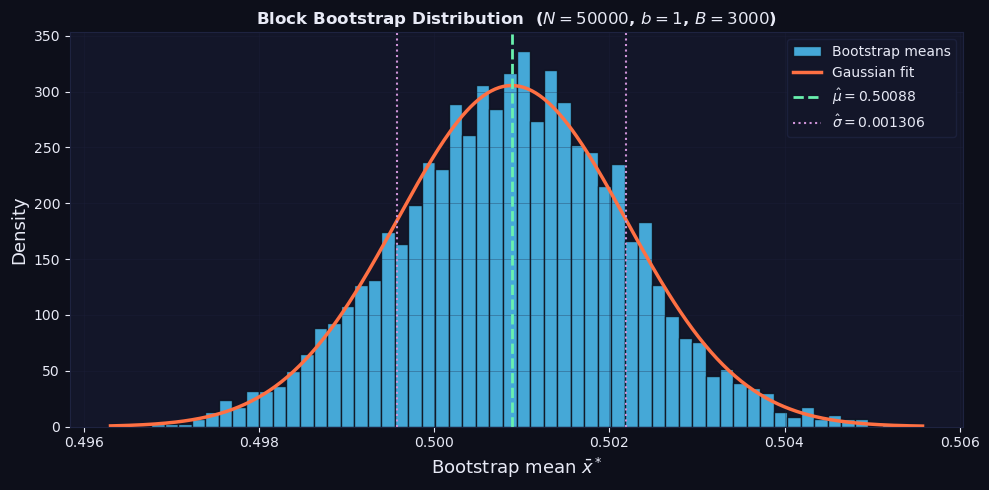

In [12]:
# ── Plot bootstrap distribution ───────────────────────────────────────
mu_b  = boot_means.mean()
sig_b = boot_means.std(ddof=1)
t_vals = np.linspace(boot_means.min(), boot_means.max(), 400)
gauss  = (np.exp(-0.5*((t_vals - mu_b)/sig_b)**2)
          / (sig_b * np.sqrt(2*np.pi)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(boot_means, bins=60, color=ACCENT, edgecolor=BG,
        alpha=0.85, density=True, label='Bootstrap means')
ax.plot(t_vals, gauss, color=WARM, lw=2.5, label='Gaussian fit')
ax.axvline(mu_b, color=GREEN, lw=2, ls='--',
           label=f'$\\hat{{\\mu}}={mu_b:.5f}$')
ax.axvline(mu_b - sig_b, color=PURPLE, lw=1.5, ls=':')
ax.axvline(mu_b + sig_b, color=PURPLE, lw=1.5, ls=':',
           label=f'$\\hat{{\\sigma}}={sig_b:.6f}$')
ax.set_xlabel('Bootstrap mean $\\bar{x}^*$', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title(f'Block Bootstrap Distribution  '
             f'($N={N}$, $b={block_size}$, $B=3000$)',
             fontweight='bold', color=TEXT)
ax.legend(fontsize=10); ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()


---
## 9. Comparison Across Sample Sizes <a id='9-comparison'></a>

We verify that all three estimators scale as $1/\sqrt{N}$ and converge
to the exact value $1/\sqrt{12N}$ for the uniform distribution.


In [ ]:
N_values = [500, 1000, 5000, 10_000, 50_000]
results  = {}

for Nv in N_values:
    xv      = generate_sample(Nv, seed=SEED)
    acfv    = autocorrelation(xv, max_lag=min(Nv//2, 500))
    tv, _   = integrated_autocorrelation_time(acfv)
    blk     = max(1, int(2 * tv))
    s_n     = std_naive(xv)
    s_c     = std_with_covariance(xv, tv)
    s_b, _  = std_bootstrap(xv, n_boot=1000, block_size=blk, seed=0)
    results[Nv] = dict(naive=s_n, corr=s_c, boot=s_b,
                        tau=tv, exact=1/(np.sqrt(12)*np.sqrt(Nv)))
    print(f"N={Nv:>6d}  tau={tv:.3f}  "
          f"naive={s_n:.6f}  corr={s_c:.6f}  "
          f"boot={s_b:.6f}  exact={results[Nv]['exact']:.6f}")


In [ ]:
# ── Comparison plots ──────────────────────────────────────────────────
labels = ['naive', 'corr', 'boot', 'exact']
colors = [ACCENT, WARM, GREEN, PURPLE]
names  = ['Naive  $\\sigma_N$', 'Covariance-corrected',
          'Block bootstrap', 'Exact  $1/\\sqrt{12N}$']
styles = ['o-', 's-', '^-', '--']

Nv_arr = np.array(N_values)
data_arr = {k: np.array([results[Nv][k] for Nv in N_values]) for k in labels}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for k, col, nm, st in zip(labels, colors, names, styles):
    ax1.plot(Nv_arr, data_arr[k], st, color=col, lw=2, ms=6, label=nm)
ax1.set_xlabel('Sample size $N$', fontsize=13)
ax1.set_ylabel('$\\sigma_{\\bar{x}}$', fontsize=13)
ax1.set_title('$\\sigma_{\\bar{x}}$ vs $N$', fontweight='bold', color=TEXT)
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.35)

for k, col, nm, st in zip(labels, colors, names, styles):
    ax2.loglog(Nv_arr, data_arr[k], st, color=col, lw=2, ms=6, label=nm)
ax2.set_xlabel('$N$  (log)', fontsize=13)
ax2.set_ylabel('$\\sigma_{\\bar{x}}$  (log)', fontsize=13)
ax2.set_title('Log–Log: $1/\\sqrt{N}$ Scaling', fontweight='bold', color=TEXT)
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.35, which='both')

plt.suptitle('Three Estimators of $\\sigma_{\\bar{x}}$',
             fontsize=14, fontweight='bold', color=TEXT, y=1.01)
plt.tight_layout()
plt.show()


---
## 10. Summary <a id='10-summary'></a>


In [ ]:
print("=" * 62)
print(f"  Autocorrelation Analysis of NumPy PCG64  (N = {N})")
print("=" * 62)
print(f"  Sample mean              = {x.mean():.6f}  (true = 0.5)")
print(f"  tau_int (Sokal window)   = {tau_int:.4f}  (1/2 = uncorrelated)")
print(f"  Effective sample size    = {N/(2*tau_int):.1f}")
print()
print(f"  sigma_mean (naive)       = {sigma_naive:.8f}")
print(f"  sigma_mean (covariance)  = {sigma_corr:.8f}")
print(f"  sigma_mean (bootstrap)   = {sigma_boot:.8f}")
print(f"  sigma_mean (exact iid)   = {1/(np.sqrt(12)*np.sqrt(N)):.8f}")
print()
print("  Conclusion:")
print("  The PCG64 generator produces output that is statistically")
print("  indistinguishable from i.i.d. uniform [0,1) data:")
print(f"    tau_int ≈ 1/2  →  all three estimators agree,")
print(f"    C(t) ≈ 0 for t ≥ 1  →  no detectable autocorrelation.")


---
### Key Formulae Recap

| Quantity | Formula |
|:---|:---|
| ACF | $C(t) = \langle (x_i-\bar{x})(x_{i+t}-\bar{x})\rangle / \sigma^2$ |
| Integrated autocorrelation time | $\tau_{\rm int} = \frac{1}{2} + \sum_{t=1}^{W} C(t)$ |
| Naive std of mean | $\sigma^{\rm naive}_{\bar{x}} = s / \sqrt{N}$ |
| Covariance-corrected std | $\sigma^{\rm corr}_{\bar{x}} = s\sqrt{2\tau_{\rm int}/N}$ |
| Block bootstrap std | $\sigma^{\rm boot}_{\bar{x}} = {\rm std}\{\bar{x}^{*(k)}\}$ |
| Exact (uniform i.i.d.) | $\sigma_{\bar{x}} = 1/\sqrt{12N}$ |

**References**

- N. Madras & A. D. Sokal, *J. Stat. Phys.* **50** (1988) 109–174.
- B. Berg, *Markov Chain Monte Carlo Simulations and Their Statistical Analysis*, World Scientific, 2004.
- U. Wolff, *Comput. Phys. Commun.* **156** (2004) 143–153.
